#Stock Price Prediction

#1. Load + SAVE Dataset

In [1]:
!pip install yfinance

import yfinance as yf
import pandas as pd

# Load data
df = yf.download("TSLA", start="2020-01-01", end="2024-01-01")

# 🔥 Save dataset (important for A+)
df.to_csv("stock_data.csv")

df.head()

/tmp/ipykernel_1464/786527039.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("TSLA", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


#2. Feature Engineering (

In [2]:
# Target
df['Target'] = df['Close'].shift(-1)

# Moving Averages
df['MA10'] = df['Close'].rolling(10).mean()
df['MA50'] = df['Close'].rolling(50).mean()

# Daily Return
df['Return'] = df['Close'].pct_change()

# Drop NaN
df = df.dropna()

# Features
X = df[['Open', 'High', 'Low', 'Volume', 'MA10', 'MA50', 'Return']]
y = df['Target']

#3. Visualization

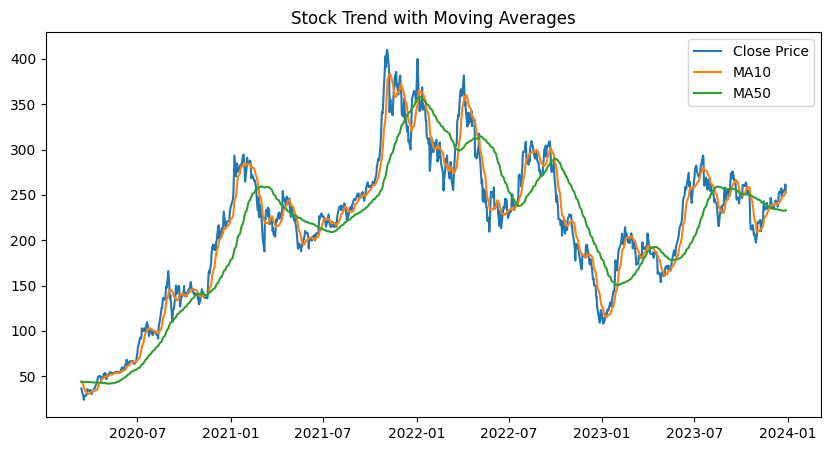

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label="Close Price")
plt.plot(df['MA10'], label="MA10")
plt.plot(df['MA50'], label="MA50")
plt.legend()
plt.title("Stock Trend with Moving Averages")
plt.show()

#4. Model Training

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Better model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

#5. Evaluation

In [5]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict
y_pred = model.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MAE:", mae)
print("MAPE:", mape)

MAE: 6.318360465392982
MAPE: 2.8088059227668083


#6. Actual vs Predicted

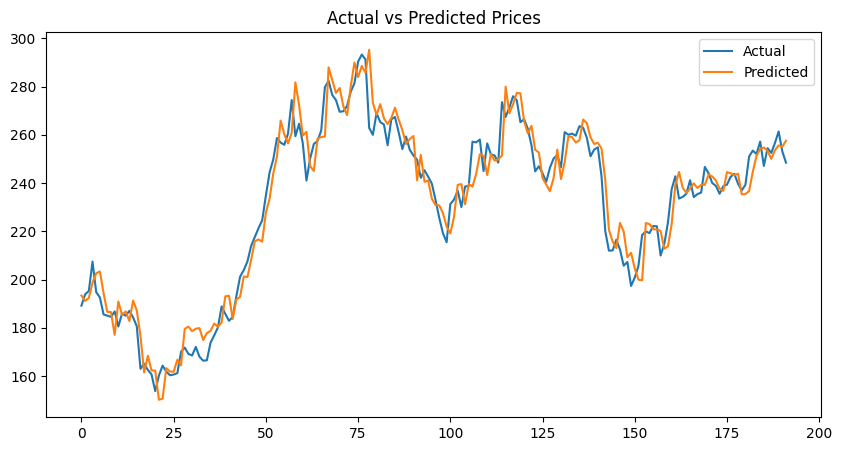

In [6]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

#7. Feature Importance

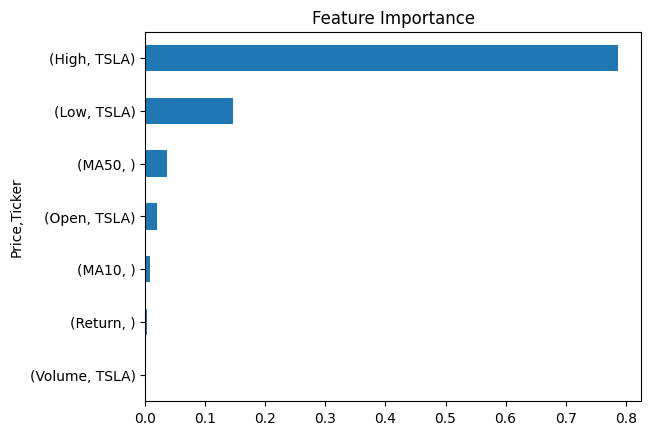

In [7]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
